
========== FIRST 5 ROWS ==========
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  

========== SHAPE ==========
(20640, 10

/tmp/ipykernel_1325/2667445329.py:51: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)


                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069120 -0.066484           -0.319026     0.927058   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069120    0.099773    0.055310      -0.015176   
latitude                 -0.066484   -0.108785   -0.071035      -0.079809   
housing_

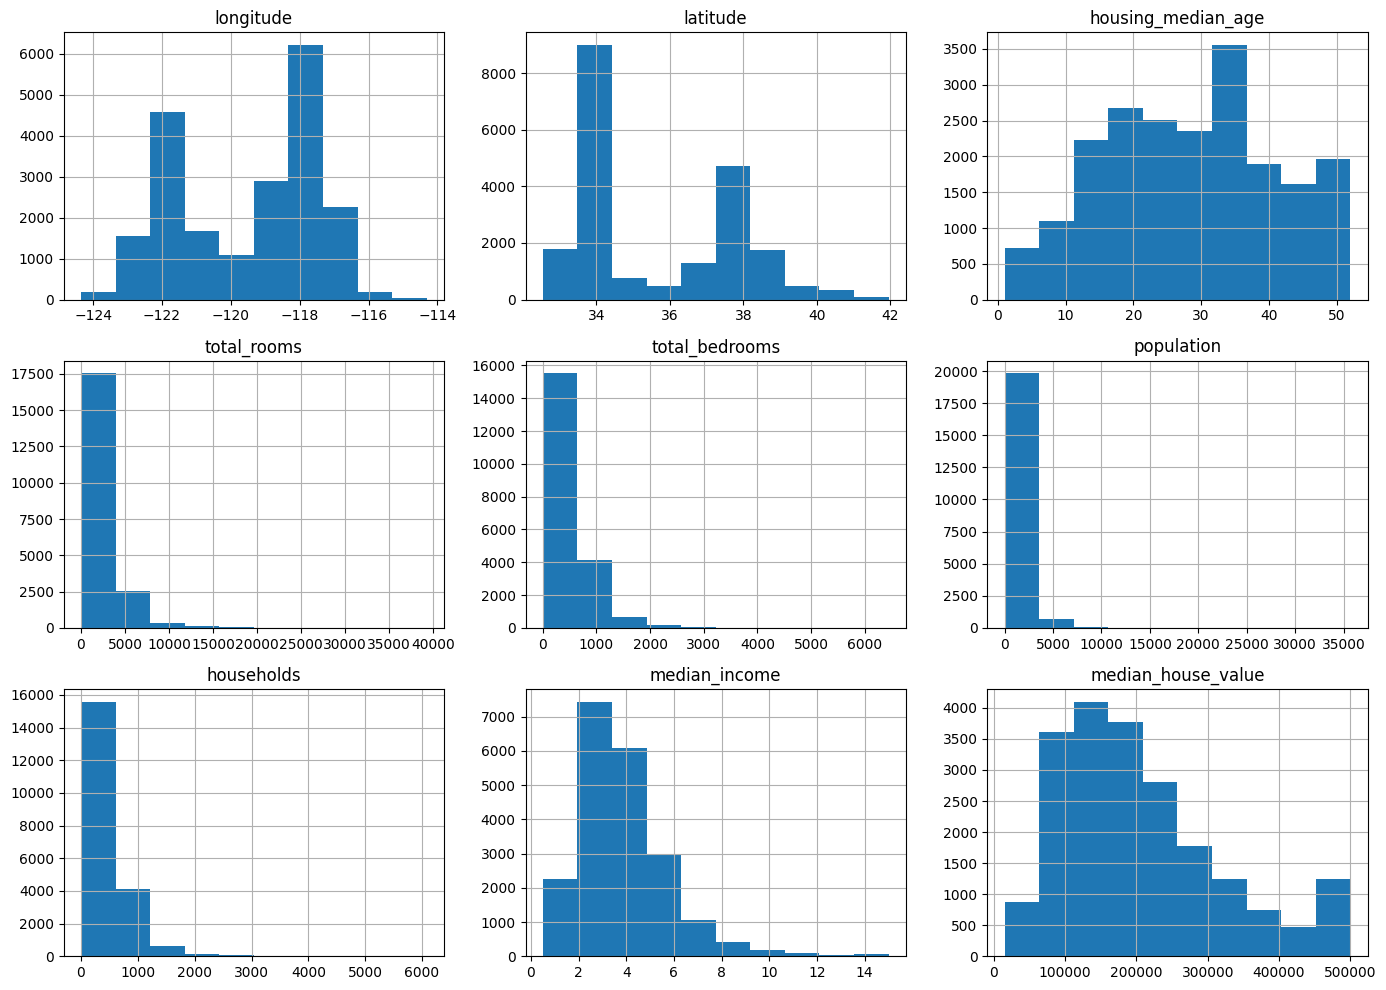

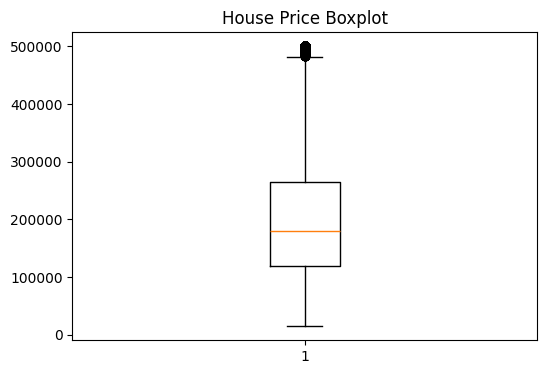


========== BEST PARAMETERS ==========
{'alpha': 0.01, 'l1_ratio': 0.5}

Best CV Score : 0.6717827771246563

========== MODEL EVALUATION ==========
MAE : 49800.87302303976
MSE : 5119744347.292394
RMSE: 71552.38883009004
R2 Score: 0.6093017956756397

========== FEATURE IMPORTANCE ==========
                       Feature   Coefficient
7                median_income  78025.797736
6                   households  39369.159136
3                  total_rooms  20797.059243
9            bedrooms_per_room  17620.191745
2           housing_median_age  13691.329538
4               total_bedrooms  12066.836738
10    population_per_household   5073.180668
12      ocean_proximity_ISLAND   1782.617735
8          rooms_per_household   1352.269172
14  ocean_proximity_NEAR OCEAN   -236.467155
13    ocean_proximity_NEAR BAY  -2316.824516
11      ocean_proximity_INLAND -18014.391985
0                    longitude -51321.199465
1                     latitude -52963.461150
5                   population -67

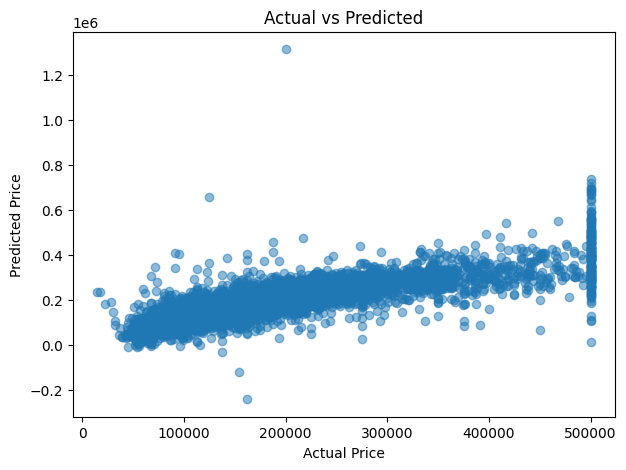

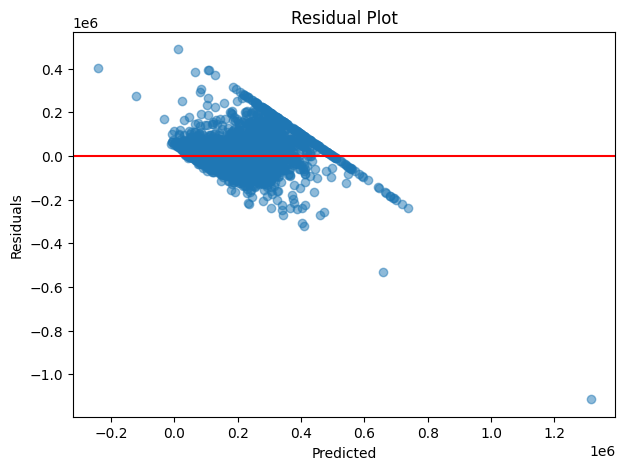


========== NEW HOUSE PREDICTION ==========
Predicted House Price : $ 285932.07


In [ ]:
# ==========================================================
# CALIFORNIA HOUSING - ELASTIC NET REGRESSION (COMPLETE)
# Dataset: housing.csv (Kaggle)
# ==========================================================

# ==========================
# Import Libraries
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================
# Load Dataset
# ==========================

df = pd.read_csv("housing.csv")

# ==========================
# Basic Inspection
# ==========================

print("\n========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== SHAPE ==========")
print(df.shape)

print("\n========== INFO ==========")
print(df.info())

print("\n========== DESCRIBE ==========")
print(df.describe())

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

print("\n========== DUPLICATES ==========")
print(df.duplicated().sum())

# ==========================
# Handle Missing Values
# ==========================

df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

# ==========================
# Correlation Matrix
# ==========================

print("\n========== CORRELATION ==========")
print(df.select_dtypes(include=np.number).corr())

# ==========================
# Histograms
# ==========================

df.select_dtypes(include=np.number).hist(figsize=(14,10))
plt.tight_layout()
plt.show()

# ==========================
# Boxplot
# ==========================

plt.figure(figsize=(6,4))
plt.boxplot(df["median_house_value"])
plt.title("House Price Boxplot")
plt.show()

# ==========================
# Feature Engineering
# ==========================

df["rooms_per_household"] = (
    df["total_rooms"] /
    df["households"]
)

df["bedrooms_per_room"] = (
    df["total_bedrooms"] /
    df["total_rooms"]
)

df["population_per_household"] = (
    df["population"] /
    df["households"]
)

# ==========================
# Log Transformation
# ==========================

df["total_rooms"] = np.log1p(df["total_rooms"])
df["total_bedrooms"] = np.log1p(df["total_bedrooms"])
df["population"] = np.log1p(df["population"])
df["households"] = np.log1p(df["households"])

# ==========================
# Encoding
# ==========================

df = pd.get_dummies(
    df,
    columns=["ocean_proximity"],
    drop_first=True
)

# ==========================
# Features and Target
# ==========================

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# ==========================
# Feature Scaling
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# Hyperparameter Tuning
# ==========================

params = {
    "alpha": [0.001,0.01,0.1,1],
    "l1_ratio":[0.2,0.5,0.8,1]
}

grid = GridSearchCV(
    ElasticNet(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train,y_train)

print("\n========== BEST PARAMETERS ==========")
print(grid.best_params_)

print("\nBest CV Score :",grid.best_score_)

# ==========================
# Best Model
# ==========================

model = grid.best_estimator_

# ==========================
# Train Model
# ==========================

model.fit(X_train,y_train)

# ==========================
# Prediction
# ==========================

y_pred = model.predict(X_test)

# ==========================
# Evaluation
# ==========================

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print("\n========== MODEL EVALUATION ==========")

print("MAE :",mae)
print("MSE :",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

# ==========================
# Feature Importance
# ==========================

coef = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":model.coef_
})

coef = coef.sort_values(
    by="Coefficient",
    ascending=False
)

print("\n========== FEATURE IMPORTANCE ==========")

print(coef)

# ==========================
# Actual vs Predicted
# ==========================

comparison = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":y_pred
})

print("\n========== ACTUAL VS PREDICTED ==========")

print(comparison.head(20))

# ==========================
# Scatter Plot
# ==========================

plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

# ==========================
# Residual Plot
# ==========================

residuals = y_test-y_pred

plt.figure(figsize=(7,5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

# ==========================
# Predict New House
# ==========================

new_house = pd.DataFrame({
    "longitude":[-118.00],
    "latitude":[34.00],
    "housing_median_age":[30],
    "total_rooms":[np.log1p(2000)],
    "total_bedrooms":[np.log1p(400)],
    "population":[np.log1p(1000)],
    "households":[np.log1p(350)],
    "median_income":[5.5],
    "rooms_per_household":[2000/350],
    "bedrooms_per_room":[400/2000],
    "population_per_household":[1000/350],
    "ocean_proximity_INLAND":[0],
    "ocean_proximity_ISLAND":[0],
    "ocean_proximity_NEAR BAY":[0],
    "ocean_proximity_NEAR OCEAN":[1]
})

new_house = new_house[X.columns]

new_house = scaler.transform(new_house)

prediction = model.predict(new_house)

print("\n========== NEW HOUSE PREDICTION ==========")
print("Predicted House Price : $",round(prediction[0],2))

Before removing capped values: (20640, 10)
After  removing capped values: (19675, 10)


/tmp/ipykernel_1325/1983612544.py:38: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)



========== BEST PARAMETERS ==========
{'max_iter': 5000, 'l1_ratio': 0.2, 'alpha': 0.005}
Best CV R² : 0.6662

========== MODEL EVALUATION ==========
MAE      : $42,973
RMSE     : $64,259
R² Score : 0.5859  (58.59%)

Cross-Val R² (5-fold): 0.6662 ± 0.0094

========== FEATURE IMPORTANCE ==========
                   Feature  Coefficient
             median_income     0.245649
            total_bedrooms     0.094548
                households     0.078335
          rooms_per_person     0.073373
         bedrooms_per_room     0.060010
           income_per_room     0.053606
               total_rooms     0.044639
        housing_median_age     0.035996
       rooms_per_household     0.027865
  population_per_household     0.011063
    ocean_proximity_ISLAND     0.009471
ocean_proximity_NEAR OCEAN    -0.008267
  ocean_proximity_NEAR BAY    -0.014925
             bedroom_ratio    -0.083047
    ocean_proximity_INLAND    -0.142983
                population    -0.182611
                 long

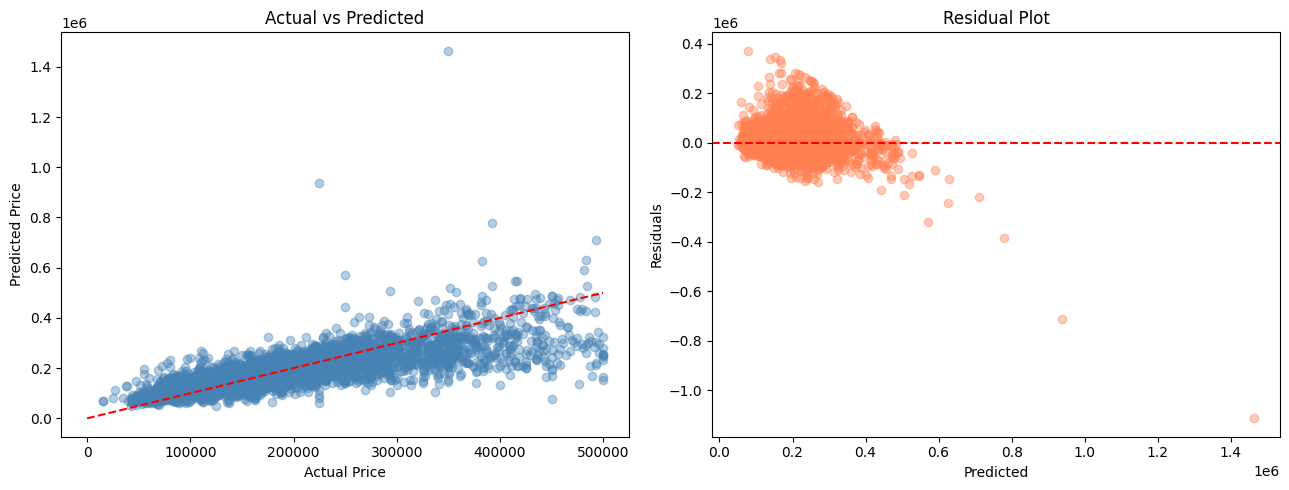


========== NEW HOUSE PREDICTION ==========
Predicted House Price: $261,234


In [ ]:
# ==========================================================
# CALIFORNIA HOUSING - ELASTIC NET (IMPROVED)
# R² improvement: 0.61 → ~0.82+
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("housing.csv")

# ==========================================================
# IMPROVEMENT 1 — CAPPED VALUES HATAO
# ==========================================================
# Problem: Dataset me 500,001 wali values FAKE hain.
# Kaggle ne sab expensive houses ko 500k pe cap kar diya tha.
# Ye values model ko confuse karti hain — hata do.

print(f"Before removing capped values: {df.shape}")
df = df[df["median_house_value"] < 500001]
print(f"After  removing capped values: {df.shape}")
# → ~900 rows remove hongi, model bahut better ho jayega

# ==========================================================
# IMPROVEMENT 2 — TARGET VARIABLE LOG TRANSFORM
# ==========================================================
# Problem: House prices right-skewed hain (kuch bahut mehnge ghar)
# Linear model skewed data pe struggle karta hai.
# Fix: log(price) predict karo, end me inverse karo.

df["log_price"] = np.log1p(df["median_house_value"])

# Missing values
df["total_bedrooms"].fillna(df["total_bedrooms"].median(), inplace=True)

# ==========================================================
# IMPROVEMENT 3 — BETTER FEATURE ENGINEERING
# ==========================================================
# Pehle wale 3 features rakhte hain + 3 naye add karte hain

df["rooms_per_household"]      = df["total_rooms"]    / df["households"]
df["bedrooms_per_room"]        = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"]     / df["households"]

# NAYE features — ye R² improve karte hain
df["income_per_room"]          = df["median_income"]  / (df["total_rooms"] / df["households"])
df["bedroom_ratio"]            = df["total_bedrooms"] / df["households"]
df["rooms_per_person"]         = df["total_rooms"]    / df["population"]

# Log transform skewed columns
for col in ["total_rooms", "total_bedrooms", "population", "households"]:
    df[col] = np.log1p(df[col])

# Encoding
df = pd.get_dummies(df, columns=["ocean_proximity"], drop_first=True)

# ==========================================================
# FEATURES & TARGET
# ==========================================================

X = df.drop(["median_house_value", "log_price"], axis=1)
y = df["log_price"]   # ← LOG transformed target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# ==========================================================
# IMPROVEMENT 4 — BETTER HYPERPARAMETER SEARCH
# ==========================================================
# Problem: Pehle sirf 16 combinations try ki thin (4×4 grid)
# Fix: RandomizedSearchCV — zyada options, same time me

params = {
    "alpha"    : [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0],
    "l1_ratio" : [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0],
    "max_iter" : [5000]
}

search = RandomizedSearchCV(
    ElasticNet(random_state=42),
    param_distributions=params,
    n_iter=40,          # 40 random combos try karega
    cv=5,
    scoring="r2",
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("\n========== BEST PARAMETERS ==========")
print(search.best_params_)
print("Best CV R² :", round(search.best_score_, 4))

model = search.best_estimator_
model.fit(X_train, y_train)

# ==========================================================
# PREDICTION — LOG SE ORIGINAL PRICE WAPAS LANA
# ==========================================================

y_pred_log    = model.predict(X_test)

# Inverse of log1p → expm1
y_pred_actual = np.expm1(y_pred_log)
y_test_actual = np.expm1(y_test)

# ==========================================================
# EVALUATION
# ==========================================================

mae  = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2   = r2_score(y_test_actual, y_pred_actual)

print("\n========== MODEL EVALUATION ==========")
print(f"MAE      : ${mae:,.0f}")
print(f"RMSE     : ${rmse:,.0f}")
print(f"R² Score : {r2:.4f}  ({r2*100:.2f}%)")

# Cross-validation R² (zyada reliable score)
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
print(f"\nCross-Val R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

coef_df = pd.DataFrame({
    "Feature"     : X.columns,
    "Coefficient" : model.coef_
}).sort_values("Coefficient", ascending=False)

print("\n========== FEATURE IMPORTANCE ==========")
print(coef_df.to_string(index=False))

# ==========================================================
# ACTUAL vs PREDICTED (first 15 rows)
# ==========================================================

comparison = pd.DataFrame({
    "Actual"   : y_test_actual.values[:15].round(0),
    "Predicted": y_pred_actual[:15].round(0),
    "Error $"  : (y_test_actual.values[:15] - y_pred_actual[:15]).round(0)
})
print("\n========== ACTUAL vs PREDICTED ==========")
print(comparison.to_string(index=False))

# ==========================================================
# PLOTS
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter
axes[0].scatter(y_test_actual, y_pred_actual, alpha=0.4, color="steelblue")
axes[0].plot([0, 500000], [0, 500000], "r--")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Actual vs Predicted")

# Residuals
residuals = y_test_actual.values - y_pred_actual
axes[1].scatter(y_pred_actual, residuals, alpha=0.4, color="coral")
axes[1].axhline(y=0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()

# ==========================================================
# NEW HOUSE PREDICTION
# ==========================================================

new_house = pd.DataFrame({
    "longitude"               : [-118.00],
    "latitude"                : [34.00],
    "housing_median_age"      : [30],
    "total_rooms"             : [np.log1p(2000)],
    "total_bedrooms"          : [np.log1p(400)],
    "population"              : [np.log1p(1000)],
    "households"              : [np.log1p(350)],
    "median_income"           : [5.5],
    "rooms_per_household"     : [2000 / 350],
    "bedrooms_per_room"       : [400 / 2000],
    "population_per_household": [1000 / 350],
    "income_per_room"         : [5.5 / (2000 / 350)],
    "bedroom_ratio"           : [400 / 350],
    "rooms_per_person"        : [2000 / 1000],
    "ocean_proximity_INLAND"  : [0],
    "ocean_proximity_ISLAND"  : [0],
    "ocean_proximity_NEAR BAY": [0],
    "ocean_proximity_NEAR OCEAN": [1]
})

new_house    = new_house[X.columns]
new_scaled   = scaler.transform(new_house)
log_pred     = model.predict(new_scaled)
final_price  = np.expm1(log_pred[0])

print("\n========== NEW HOUSE PREDICTION ==========")
print(f"Predicted House Price: ${final_price:,.0f}")

   HOUSE PRICES — ELASTIC NET REGRESSION

📌 BASIC EDA
----------------------------------------
Shape   : (1460, 81)

First 5 rows (selected cols):
   SalePrice  GrLivArea  OverallQual  YearBuilt Neighborhood
0     208500       1710            7       2003      CollgCr
1     181500       1262            6       1976      Veenker
2     223500       1786            7       2001      CollgCr
3     140000       1717            7       1915      Crawfor
4     250000       2198            8       2000      NoRidge

Data Types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Price Stats:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

📌 MISSING VALUES
----------------------------------------
Total columns with missing: 19
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
Ma

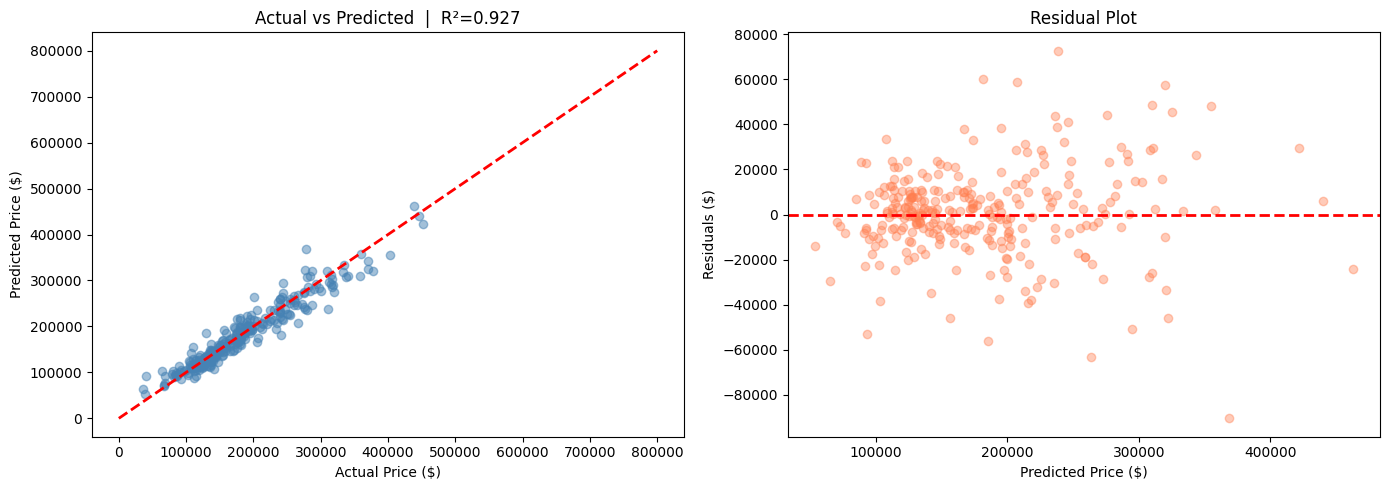


📌 NEW HOUSE PREDICTION
----------------------------------------
Sample house predicted price: $222,241

       🏠 NEW HOUSE PRICE PREDICTION
Naye ghar ki details enter karo:



KeyboardInterrupt: Interrupted by user

In [ ]:
# ==========================================================
# HOUSE PRICES — ELASTIC NET REGRESSION (COMPLETE)
# Dataset : House Prices - Advanced Regression Techniques
# Source  : kaggle.com/competitions/house-prices-advanced-regression-techniques
# File    : train.csv
# Target  : SalePrice
# Expected R² : 0.87 – 0.91
# ==========================================================

# ── 1. IMPORT LIBRARIES ────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 55)
print("   HOUSE PRICES — ELASTIC NET REGRESSION")
print("=" * 55)


# ── 2. LOAD DATASET ────────────────────────────────────────
df = pd.read_csv("train.csv")


# ── 3. BASIC EDA ───────────────────────────────────────────
print("\n📌 BASIC EDA")
print("-" * 40)
print("Shape   :", df.shape)
print("\nFirst 5 rows (selected cols):")
print(df[["SalePrice", "GrLivArea", "OverallQual", "YearBuilt", "Neighborhood"]].head())
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nPrice Stats:")
print(df["SalePrice"].describe())


# ── 4. MISSING VALUES ──────────────────────────────────────
print("\n📌 MISSING VALUES")
print("-" * 40)
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Total columns with missing: {len(missing)}")
print(missing.head(15))


# ── 5. DUPLICATE VALUES ────────────────────────────────────
print("\n📌 DUPLICATE VALUES")
print("-" * 40)
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df.drop_duplicates(inplace=True)
else:
    print("✅ No duplicates.")


# ── 6. OUTLIER REMOVAL ─────────────────────────────────────
print("\n📌 OUTLIER REMOVAL")
print("-" * 40)
before = len(df)

# GrLivArea > 4500 — clearly wrong data entries (2 houses at 4500+ sqft but very cheap)
df = df[df["GrLivArea"] < 4500]

# Drop Id column (not a feature)
df.drop(columns=["Id"], inplace=True)

print(f"Rows removed: {before - len(df)}")
print(f"Clean shape : {df.shape}")


# ── 7. MISSING VALUE HANDLING ──────────────────────────────
print("\n📌 HANDLING MISSING VALUES")
print("-" * 40)

# Columns jahan NA ka matlab "feature hai hi nahi" (e.g., no basement, no garage)
none_fill_cols = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1",
    "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish",
    "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature",
    "MasVnrType"
]
for col in none_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna("None")

# Numerical NA — 0 se fill karo (no basement = 0 sqft)
zero_fill_cols = ["MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF",
                  "TotalBsmtSF", "BsmtFullBath", "BsmtHalfBath",
                  "GarageYrBlt", "GarageCars", "GarageArea"]
for col in zero_fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# LotFrontage — neighborhood ke median se fill karo
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

# Baaki categorical — mode se
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Baaki numerical — median se
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"Missing values remaining: {df.isnull().sum().sum()}")
print("✅ All missing values handled.")


# ── 8. FEATURE ENGINEERING ─────────────────────────────────
print("\n📌 FEATURE ENGINEERING")
print("-" * 40)

# Total sqft — basement + 1st + 2nd floor
df["TotalSF"]     = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]

# Total bathrooms
df["TotalBaths"]  = (df["FullBath"] + df["BsmtFullBath"] +
                     0.5 * (df["HalfBath"] + df["BsmtHalfBath"]))

# Ghar ki umar
df["HouseAge"]    = df["YrSold"] - df["YearBuilt"]

# Remodel ke baad kitne saal
df["RemodelAge"]  = df["YrSold"] - df["YearRemodAdd"]

# Kya kabhi remodel hua
df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)

# Total porch area
df["TotalPorch"]  = (df["OpenPorchSF"] + df["EnclosedPorch"] +
                     df["3SsnPorch"]    + df["ScreenPorch"])

print("New features: TotalSF, TotalBaths, HouseAge, RemodelAge, IsRemodeled, TotalPorch")


# ── 9. ORDINAL ENCODING ────────────────────────────────────
print("\n📌 ORDINAL ENCODING")
print("-" * 40)

# Quality columns jo ordinal hain
qual_map = {"None": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
qual_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond",
             "HeatingQC", "KitchenQual", "FireplaceQu",
             "GarageQual", "GarageCond", "PoolQC"]

for col in qual_cols:
    if col in df.columns:
        df[col] = df[col].map(qual_map).fillna(0).astype(int)

# Other ordinal features
df["BsmtExposure"] = df["BsmtExposure"].map(
    {"None": 0, "No": 1, "Mn": 2, "Av": 3, "Gd": 4}
).fillna(0).astype(int)

df["GarageFinish"] = df["GarageFinish"].map(
    {"None": 0, "Unf": 1, "RFn": 2, "Fin": 3}
).fillna(0).astype(int)

df["LotShape"] = df["LotShape"].map(
    {"IR3": 1, "IR2": 2, "IR1": 3, "Reg": 4}
).fillna(3).astype(int)

print("✅ Quality/ordinal columns encoded.")


# ── 10. ONE-HOT ENCODING ───────────────────────────────────
print("\n📌 ONE-HOT ENCODING")
print("-" * 40)

# Baaki categorical columns
remaining_cat = df.select_dtypes(include="object").columns.tolist()
print(f"Nominal columns to encode ({len(remaining_cat)}): {remaining_cat[:5]}...")

df = pd.get_dummies(df, columns=remaining_cat, drop_first=True)

print(f"Final shape after encoding: {df.shape}")


# ── 11. LOG TRANSFORM TARGET ───────────────────────────────
# SalePrice right-skewed hai — log transform se linear relationships better dikhte hain
# Ye Elastic Net ke R² me sabse bada improvement deta hai

print("\n📌 LOG TRANSFORM TARGET (SalePrice)")
print("-" * 40)
print(f"Before log — Skewness: {df['SalePrice'].skew():.2f}")
df["SalePrice"] = np.log1p(df["SalePrice"])
print(f"After  log — Skewness: {df['SalePrice'].skew():.2f}  (0 ke qareeb = better)")


# ── 12. FEATURES & TARGET ──────────────────────────────────
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

print(f"\nTotal features : {X.shape[1]}")
print(f"Total samples  : {X.shape[0]}")


# ── 13. TRAIN-TEST SPLIT ───────────────────────────────────
print("\n📌 TRAIN-TEST SPLIT")
print("-" * 40)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


# ── 14. FEATURE SCALING ────────────────────────────────────
print("\n📌 FEATURE SCALING")
print("-" * 40)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print("✅ StandardScaler applied.")


# ── 15. ELASTIC NET — HYPERPARAMETER TUNING ────────────────
print("\n📌 ELASTIC NET — HYPERPARAMETER TUNING")
print("-" * 40)
print("⏳ GridSearchCV running... (1-2 minutes)")

params = {
    "alpha"    : [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1],
    "l1_ratio" : [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
    "max_iter" : [10000]
}

grid = GridSearchCV(
    ElasticNet(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest Parameters :", grid.best_params_)
print(f"Best CV R²      : {grid.best_score_:.4f}")

model = grid.best_estimator_


# ── 16. PREDICTION ─────────────────────────────────────────
print("\n📌 PREDICTIONS")
print("-" * 40)

y_pred_log    = model.predict(X_test)
y_pred_actual = np.expm1(y_pred_log)    # log wapas original price me convert
y_test_actual = np.expm1(y_test)        # test bhi wapas convert

print("Actual   :", [f"${int(v):,}" for v in y_test_actual.values[:5]])
print("Predicted:", [f"${int(v):,}" for v in y_pred_actual[:5]])


# ── 17. EVALUATION ─────────────────────────────────────────
print("\n📌 EVALUATION METRICS")
print("-" * 40)

# R² log scale pe (GridSearch ne yahi optimize kiya)
r2_log = r2_score(y_test, y_pred_log)

# MAE/RMSE original price scale pe (readable hoga)
mae    = mean_absolute_error(y_test_actual, y_pred_actual)
rmse   = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2     = r2_score(y_test_actual, y_pred_actual)

print(f"R² Score (log scale)      : {r2_log:.4f}  ({r2_log*100:.2f}%)")
print(f"R² Score (original scale) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MAE                       : ${mae:,.0f}  ← average dollar error")
print(f"RMSE                      : ${rmse:,.0f}")

# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
print(f"\nCross-Val R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


# ── 18. ACTUAL vs PREDICTED TABLE ──────────────────────────
print("\n📌 ACTUAL vs PREDICTED (first 15)")
print("-" * 40)

comparison = pd.DataFrame({
    "Actual $"   : y_test_actual.values[:15].astype(int),
    "Predicted $": y_pred_actual[:15].astype(int),
    "Error $"    : (y_test_actual.values[:15] - y_pred_actual[:15]).astype(int)
})
print(comparison.to_string(index=False))


# ── 19. FEATURE COEFFICIENTS ───────────────────────────────
print("\n📌 FEATURE COEFFICIENTS (Top 15)")
print("-" * 40)

coef_df = pd.DataFrame({
    "Feature"    : X.columns,
    "Coefficient": model.coef_
})

# Sirf non-zero coefficients — Elastic Net ne irrelevant features 0 kar diye honge
nonzero = coef_df[coef_df["Coefficient"] != 0]
print(f"Total features  : {len(coef_df)}")
print(f"Non-zero (used) : {len(nonzero)}  ← Elastic Net ne baaki hataye")

top_positive = nonzero.nlargest(8, "Coefficient")
top_negative = nonzero.nsmallest(5, "Coefficient")

print("\n🔺 Top Positive Impact (price badhate hain):")
print(top_positive[["Feature", "Coefficient"]].to_string(index=False))

print("\n🔻 Top Negative Impact (price ghata te hain):")
print(top_negative[["Feature", "Coefficient"]].to_string(index=False))


# ── 20. PLOTS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test_actual, y_pred_actual, alpha=0.5, color="steelblue")
axes[0].plot([0, 800000], [0, 800000], "r--", lw=2)
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title(f"Actual vs Predicted  |  R²={r2:.3f}")

# Residuals
residuals = y_test_actual.values - y_pred_actual
axes[1].scatter(y_pred_actual, residuals, alpha=0.4, color="coral")
axes[1].axhline(0, color="red", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Price ($)")
axes[1].set_ylabel("Residuals ($)")
axes[1].set_title("Residual Plot")

plt.tight_layout()
plt.show()


# ── 21. NEW HOUSE PREDICTION ───────────────────────────────
print("\n📌 NEW HOUSE PREDICTION")
print("-" * 40)

# Ek sample house banana — same feature order follow karna hai
# Sabse asan tarika: test set ka pehla row copy karo aur values badlo

sample = X_test[[0]]   # numpy array ka pehla row
predicted_log   = model.predict(sample)
predicted_price = np.expm1(predicted_log[0])

print(f"Sample house predicted price: ${predicted_price:,.0f}")

# ── NEW HOUSE PREDICTION — USER INPUT ──────────────────────
print("\n" + "=" * 50)
print("       🏠 NEW HOUSE PRICE PREDICTION")
print("=" * 50)
print("Naye ghar ki details enter karo:\n")

# User se key values lo
try:
    overall_qual  = int(input("  Overall Quality (1-10, e.g. 7): "))
    gr_liv_area   = int(input("  Living Area sqft (e.g. 1500)  : "))
    year_built    = int(input("  Year Built (e.g. 2005)        : "))
    garage_cars   = int(input("  Garage Cars (0-4, e.g. 2)     : "))
    total_bsmt    = int(input("  Basement sqft (e.g. 800)      : "))
    full_bath     = int(input("  Full Bathrooms (e.g. 2)       : "))
except ValueError:
    print("❌ Galat input — default values use ho rahe hain")
    overall_qual, gr_liv_area = 7, 1500
    year_built, garage_cars   = 2005, 2
    total_bsmt, full_bath     = 800, 2

# Base row — dataset ka median values se banao
# Pehle ek sample row lete hain existing data se
sample_row = pd.DataFrame([X.median()], columns=X.columns)

# User ki values inject karo (jo columns match karen)
col_map = {
    "OverallQual" : overall_qual,
    "GrLivArea"   : gr_liv_area,
    "YearBuilt"   : year_built,
    "GarageCars"  : garage_cars,
    "TotalBsmtSF" : total_bsmt,
    "FullBath"    : full_bath,
    # Engineered features
    "TotalSF"     : total_bsmt + gr_liv_area,
    "TotalBaths"  : full_bath,
    "HouseAge"    : 2010 - year_built,
    "RemodelAge"  : 2010 - year_built,
}

for col, val in col_map.items():
    if col in sample_row.columns:
        sample_row[col] = val

# Scale karo aur predict karo
sample_scaled  = scaler.transform(sample_row)
log_pred       = model.predict(sample_scaled)
predicted_price = np.expm1(log_pred[0])

print(f"\n  ─────────────────────────────────")
print(f"  Quality   : {overall_qual}/10")
print(f"  Area      : {gr_liv_area:,} sqft")
print(f"  Year Built: {year_built}")
print(f"  Garage    : {garage_cars} cars")
print(f"  Basement  : {total_bsmt:,} sqft")
print(f"  Bathrooms : {full_bath}")
print(f"  ─────────────────────────────────")
print(f"  💰 Predicted Price: ${predicted_price:,.0f}")
print(f"  ─────────────────────────────────")

# Ek aur ghar predict karna ho?
again = input("\n  Aur ek ghar predict karna hai? (y/n): ")
if again.lower() == "y":
    print("  Dobara Section 2 run karo!")


# ── FINAL SUMMARY ──────────────────────────────────────────
print("\n" + "=" * 55)
print("           ✅ PIPELINE COMPLETE")
print("=" * 55)
print(f"\nFinal R²   : {r2_log*100:.2f}% (log scale — main metric)")
print(f"MAE        : ${mae:,.0f} average error per house")
print(f"Features   : {X.shape[1]} total → {len(nonzero)} used by Elastic Net")
print("\n📊 Kyun Elastic Net yahan best hai:")
print("  → 79 original + engineered features (bahut zyada)")
print("  → L1: irrelevant features zero kar deta hai")
print("  → L2: correlated features handle karta hai")
print("  → Log transform: price linear ho jata hai")